## Feature Engineering and Polynomial Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lab_utils_multi import zscore_normalize_features, run_gradient_descent_feng
np.set_printoptions(precision = 2)

## Polynomial Features

In [2]:
x = np.arange(0, 20, 1)
y = 1 + x ** 2
X = x.reshape(-1, 1)

model_w, model_b = run_gradient_descent_feng(X, y, iterations = 1000, alpha = 1e-2)

Iteration         0, Cost: 1.65756e+03
Iteration       100, Cost: 6.94549e+02
Iteration       200, Cost: 5.88475e+02
Iteration       300, Cost: 5.26414e+02
Iteration       400, Cost: 4.90103e+02
Iteration       500, Cost: 4.68858e+02
Iteration       600, Cost: 4.56428e+02
Iteration       700, Cost: 4.49155e+02
Iteration       800, Cost: 4.44900e+02
Iteration       900, Cost: 4.42411e+02
w,b found by gradient descent: w: [18.7], b: -52.0834


## Selecting Features

In [3]:
x = np.arange(0, 20, 1)
y = x ** 2

X = np.c_[x, x ** 2, x ** 3]

In [4]:
model_w, model_b = run_gradient_descent_feng(X, y, iterations = 10000, alpha = 1e-7)

Iteration         0, Cost: 1.14029e+03
Iteration      1000, Cost: 3.28539e+02
Iteration      2000, Cost: 2.80443e+02
Iteration      3000, Cost: 2.39389e+02
Iteration      4000, Cost: 2.04344e+02
Iteration      5000, Cost: 1.74430e+02
Iteration      6000, Cost: 1.48896e+02
Iteration      7000, Cost: 1.27100e+02
Iteration      8000, Cost: 1.08495e+02
Iteration      9000, Cost: 9.26132e+01
w,b found by gradient descent: w: [0.08 0.54 0.03], b: 0.0106


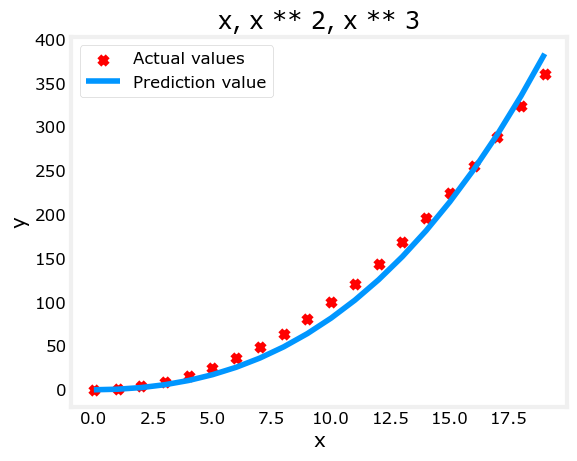

In [5]:
plt.scatter(x, y, marker = 'x', c = 'r', label = 'Actual values')
plt.title ("x, x ** 2, x ** 3")
plt.plot(x, X@model_w + model_b, label = "Prediction value")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [6]:
x = np.arange (0, 20, 1)
y = x ** 2

X = np.c_[x, x ** 2, x ** 3]
X_features = ['x', 'x^2', 'x^3']

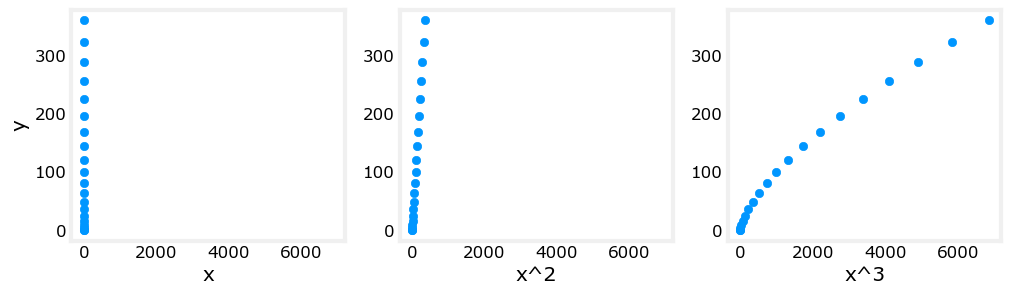

In [7]:
fig, ax = plt.subplots(1, 3, figsize = (12, 3), sharex = True)
for i in range (len(ax)):
    ax[i].scatter(X[:, i], y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("y")
plt.show()

## Scaling features
there is  𝑥, 𝑥2 and 𝑥3 which will naturally have very different scales

In [9]:
x = np.arange(0, 20, 1)
X = np.c_[x, x ** 2, x ** 3]
print(f"peak to peak range by column in raw X = {np.ptp(X, axis = 0)}")

X = zscore_normalize_features(X)
print(f"peak to peak range by column in row X = {np.ptp(X, axis = 0)} ")

peak to peak range by column in raw X = [  19  361 6859]
peak to peak range by column in row X = [3.3  3.18 3.28] 


Iteration         0, Cost: 9.42147e+03
Iteration     10000, Cost: 3.90938e-01
Iteration     20000, Cost: 2.78389e-02
Iteration     30000, Cost: 1.98242e-03
Iteration     40000, Cost: 1.41169e-04
Iteration     50000, Cost: 1.00527e-05
Iteration     60000, Cost: 7.15855e-07
Iteration     70000, Cost: 5.09763e-08
Iteration     80000, Cost: 3.63004e-09
Iteration     90000, Cost: 2.58497e-10
w,b found by gradient descent: w: [5.27e-05 1.13e+02 8.43e-05], b: 123.5000


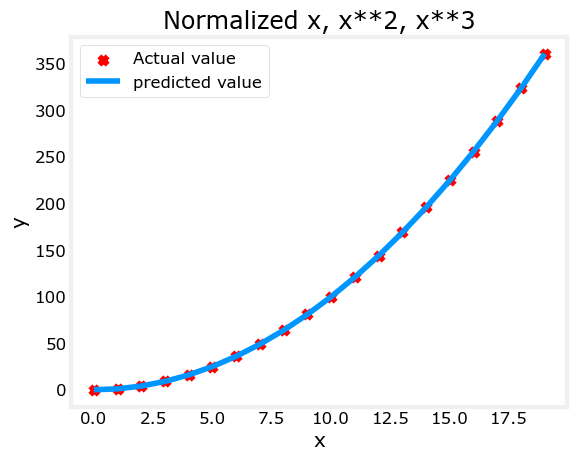

In [12]:
x = np.arange(0, 20, 1)
X = x ** 2

X = np.c_[x, x ** 2, x ** 3]
X = zscore_normalize_features(X)

model_w, model_b = run_gradient_descent_feng(X, y, iterations = 100000, alpha = 1e-1)

plt.scatter(x, y, marker = 'x', c = 'r', label = "Actual value")
plt.title("Normalized x, x**2, x**3")
plt.plot(x, X@model_w + model_b, label = "predicted value")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Complex Functions¶
With feature engineering, even quite complex functions can be modeled:

Iteration         0, Cost: 2.20188e-01
Iteration    100000, Cost: 1.70074e-02
Iteration    200000, Cost: 1.27603e-02
Iteration    300000, Cost: 9.73032e-03
Iteration    400000, Cost: 7.56440e-03
Iteration    500000, Cost: 6.01412e-03
Iteration    600000, Cost: 4.90251e-03
Iteration    700000, Cost: 4.10351e-03
Iteration    800000, Cost: 3.52730e-03
Iteration    900000, Cost: 3.10989e-03
w,b found by gradient descent: w: [ -1.34 -10.    24.78   5.96 -12.49 -16.26  -9.51   0.59   8.7   11.94
   9.27   0.79 -12.82], b: -0.0073


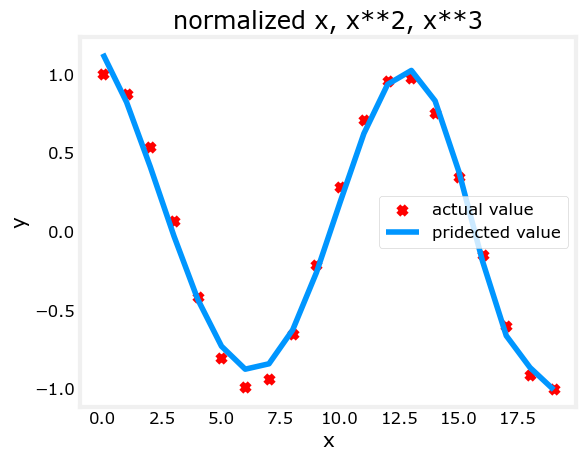

In [16]:
x = np.arange(0, 20, 1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3, x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X = zscore_normalize_features(X)

model_w, model_b = run_gradient_descent_feng(X, y, iterations = 1000000, alpha = 1e-1)

plt.scatter(x, y, marker = 'x', c ='r', label = 'actual value')
plt.title("normalized x, x**2, x**3")
plt.plot(x, X@model_w + model_b, label = "pridected value")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()